In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split

In [2]:
df_bank = pd.read_csv('/content/bank-additional-full_final.csv', sep=';')

In [3]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [4]:
df_bank.describe()
# df_bank.info()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41195.000000,41196.000000,41196.000000,41196.000000,41196.000000,41196.000000,41195.000000,41196.000000,41196.000000,41196.000000
mean,40.030319,258.281265,2.567676,962.482547,0.173124,0.081656,93.575867,-40.504600,3.620787,5166.996405
std,10.431818,259.254211,2.769751,186.893451,0.494987,1.570894,0.578999,4.629972,1.734655,72.300104
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
df_bank[~df_bank.isnull().any(axis=1)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41185,56.0,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44.0,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41193,94.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [6]:
df_bank[df_bank.isnull().any(axis=1)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41189,NaN,retired,NaN,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,NaN,-1.1,94.767,-50.8,1.028,4963.6,no
41190,74.0,NaN,married,NaN,no,yes,no,NaN,nov,fri,...,3.0,999.0,1.0,NaN,-1.1,94.767,-50.8,1.028,4963.6,no
41191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41192,74.0,retired,NaN,professional.course,NaN,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41198,74.0,retired,married,professional.course,no,yes,NaN,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,NaN,-50.8,1.028,4963.6,no


In [7]:
df_bank.shape

(41199, 21)

In [8]:
# remove null records
df_bank = df_bank.dropna()

In [9]:
df_bank.isnull().sum().sum()

np.int64(0)

In [10]:
# df_bank.duplicated()
# df_bank.any()
# df_bank.duplicated().sum()
# df_bank = df_bank[~df_bank.duplicated()]
df_bank = df_bank.drop_duplicates()

In [11]:
df_bank.shape

(41177, 21)

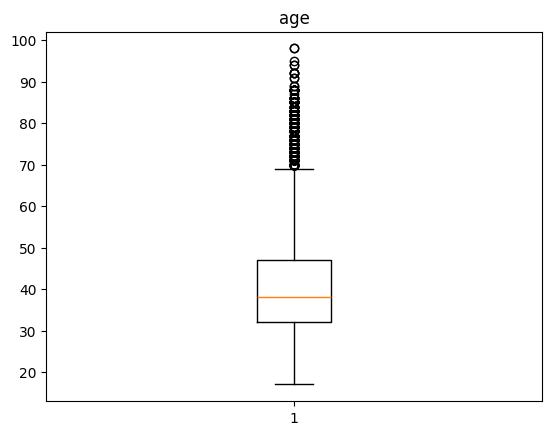

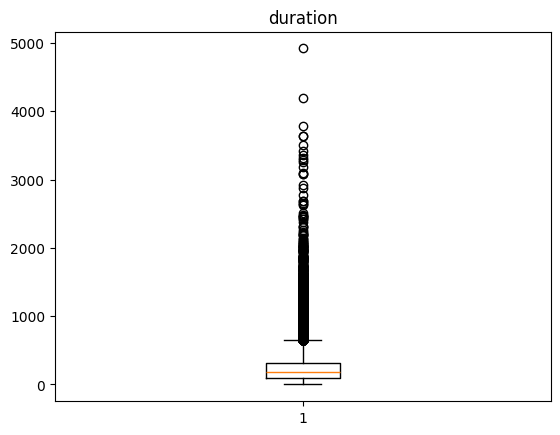

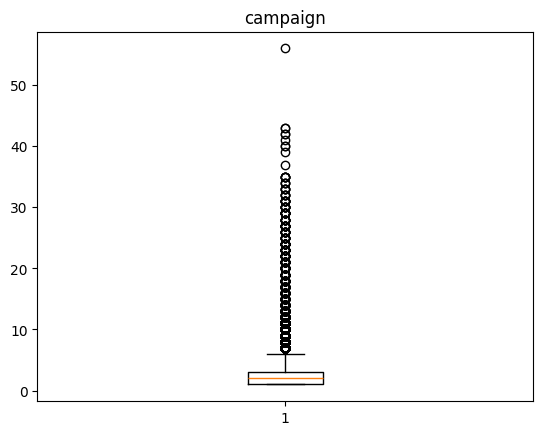

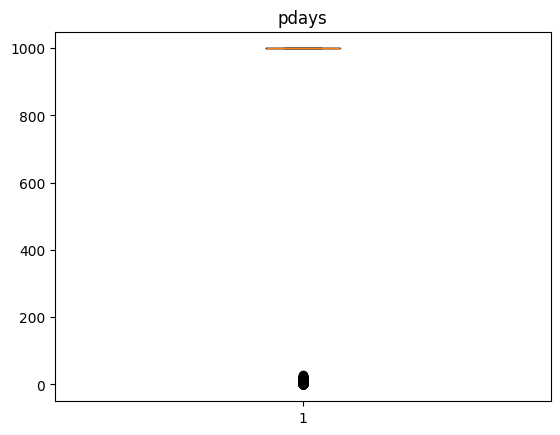

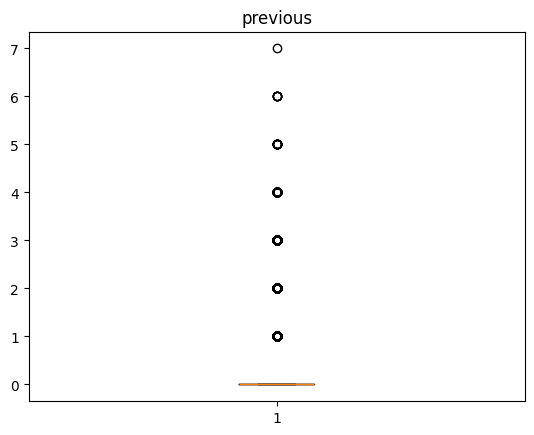

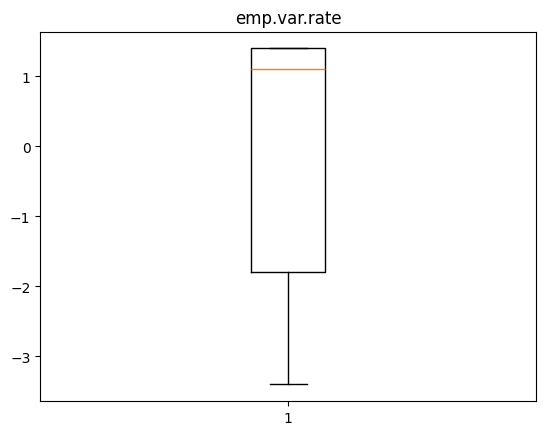

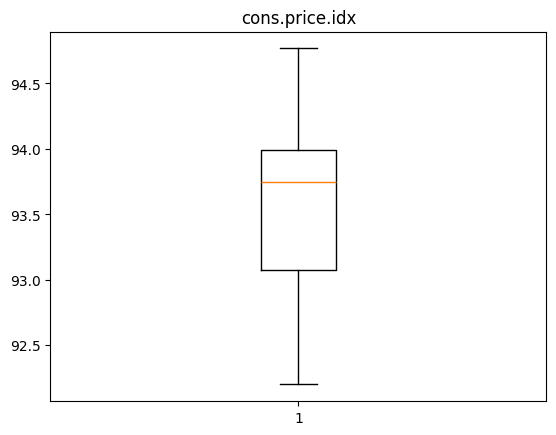

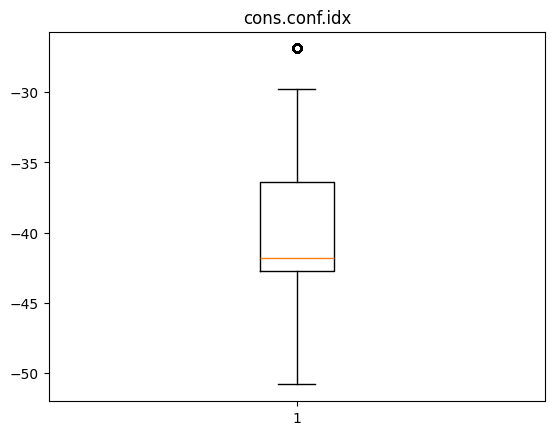

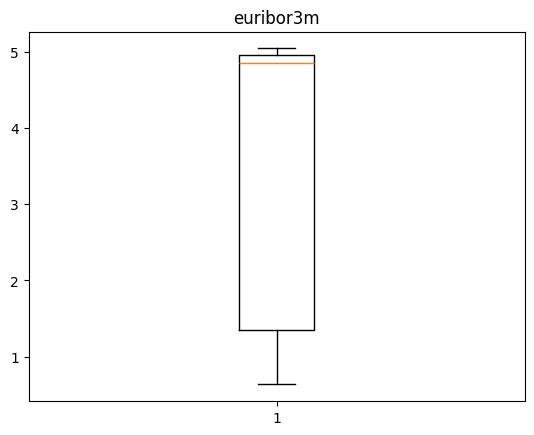

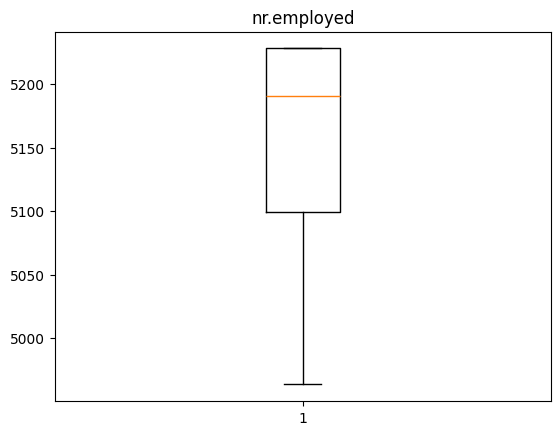

In [12]:
#check outliers using box plot
for c in df_bank.columns:
  if df_bank[c].dtype != 'object':
    plt.boxplot(df_bank[c])
    plt.title(c)
    plt.show()


In [13]:
outlier_columns = ['age', 'campaign', 'duration']

In [14]:
df_duration_temp =df_bank['duration'].value_counts().reset_index()
df_duration_temp[df_duration_temp['count'] >= 100]

,duration,count
0,85.0,170
1,90.0,170
2,136.0,168
3,73.0,167
4,124.0,163
...,...,...
141,176.0,101
142,51.0,101
143,182.0,101
144,170.0,100


In [15]:
df_bank['duration'].value_counts()

,count
duration,
85.0,170
90.0,170
136.0,168
73.0,167
124.0,163
...,...
1356.0,1
1103.0,1
1992.0,1


In [16]:
df_bank.groupby(by='duration')[['duration']].count()
# df_bank['duration'].value_counts()

,duration
duration,
0.0,4
1.0,3
2.0,1
3.0,3
4.0,12
...,...
3631.0,1
3643.0,1
3785.0,1


In [17]:
interval = pd.IntervalIndex.from_tuples([(1,100),(100,1000),(1000,2000),(2000,5000)], closed='left')
interval

IntervalIndex([[1, 100), [100, 1000), [1000, 2000), [2000, 5000)], dtype='interval[int64, left]')

In [18]:
# df_bank['duration'].value_counts()
# series_range = pd.cut(df_bank['duration'], bins=[1,10,200,500,1000,2000,5000], right=False) # return pd.Series
series_range = pd.cut(df_bank['duration'], bins=interval, right=False)
pd.DataFrame(series_range).groupby(by='duration')['duration'].count()

# pd.DataFrame(series_range).groupby(by='duration')['duration'].agg(['max', 'min', 'count'])


<ipython-input-18-1371824572>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.DataFrame(series_range).groupby(by='duration')['duration'].count()


,duration
duration,
"[1, 100)",9875
"[100, 1000)",30337
"[1000, 2000)",901
"[2000, 5000)",60


In [19]:
import pandas as pd

# Sample DataFrame
data = {'values': [1, 5, 2, 8, 10, 3, 7, 9, 4, 6]}
df = pd.DataFrame(data)

# Define the intervals
intervals = pd.IntervalIndex.from_tuples([(0, 3), (3, 6), (6, 10)], closed='left')

# Map values to intervals
df['range_group'] = pd.cut(df['values'], bins=intervals)

# Group by the range_group column
grouped_data = df.groupby('range_group')

# Aggregate the grouped data
result = grouped_data['values'].agg(['min', 'max', 'mean',])

print(result)

             min  max  mean
range_group                
[0, 3)         1    2   1.5
[3, 6)         3    5   4.0
[6, 10)        6    9   7.5


<ipython-input-19-3126554959>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby('range_group')


In [20]:
# box plot to check outliers
# for c in df_bank.columns:
#   if df_bank[c].dtype != 'object':
#     plt.boxplot(df_bank[c])
#     plt.title(c)
#     plt.show()

df_bank.shape
#  ['pdays'].value_counts()

(41177, 21)

In [21]:
# remove ouliers using iqr
# df_bank.columns
out_cols=['age', 'duration', 'campaign','cons.conf.idx']
for c in out_cols:
  q1 = df_bank[c].quantile(0.25)
  q3 = df_bank[c].quantile(0.75)
  iqr = q3 - q1
  lower_limit = q1 - iqr * 1.5
  upper_limit = q3 + iqr * 1.5
  df_bank = df_bank[(df_bank[c] >= lower_limit) & (df_bank[c] <= upper_limit)]

df_bank.shape

(35165, 21)

In [22]:
# Label encoding ;; --
# (one hot encoding - binary value)
# label_cols = ['job', 'marital', 'education',
#               'default', 'housing', 'loan', 'contact',
#               'month', 'day_of_week','poutcome', 'y']
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35165 entries, 0 to 41186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35165 non-null  float64
 1   job             35165 non-null  object 
 2   marital         35165 non-null  object 
 3   education       35165 non-null  object 
 4   default         35165 non-null  object 
 5   housing         35165 non-null  object 
 6   loan            35165 non-null  object 
 7   contact         35165 non-null  object 
 8   month           35165 non-null  object 
 9   day_of_week     35165 non-null  object 
 10  duration        35165 non-null  float64
 11  campaign        35165 non-null  float64
 12  pdays           35165 non-null  float64
 13  previous        35165 non-null  float64
 14  poutcome        35165 non-null  object 
 15  emp.var.rate    35165 non-null  float64
 16  cons.price.idx  35165 non-null  float64
 17  cons.conf.idx   35165 non-null  floa

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [24]:
for c in df_bank.columns:
  if df_bank[c].dtype == 'object':
      df_bank[c] = le.fit_transform(df_bank[c])


In [25]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35165 entries, 0 to 41186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35165 non-null  float64
 1   job             35165 non-null  int64  
 2   marital         35165 non-null  int64  
 3   education       35165 non-null  int64  
 4   default         35165 non-null  int64  
 5   housing         35165 non-null  int64  
 6   loan            35165 non-null  int64  
 7   contact         35165 non-null  int64  
 8   month           35165 non-null  int64  
 9   day_of_week     35165 non-null  int64  
 10  duration        35165 non-null  float64
 11  campaign        35165 non-null  float64
 12  pdays           35165 non-null  float64
 13  previous        35165 non-null  float64
 14  poutcome        35165 non-null  int64  
 15  emp.var.rate    35165 non-null  float64
 16  cons.price.idx  35165 non-null  float64
 17  cons.conf.idx   35165 non-null  floa

In [26]:
# Feature Selection
# VIF - Variance Inflation Factor(a measurement) - due to very sensitive correlation possible of inflation of variance lead to over fit.
#      so need to merge 2 columns or remove one column(variable) can do.
#RFE - Recursive Feature Elimination - subset of variables used recursively and idenfies which gives the better result.

# correlation

<Axes: >

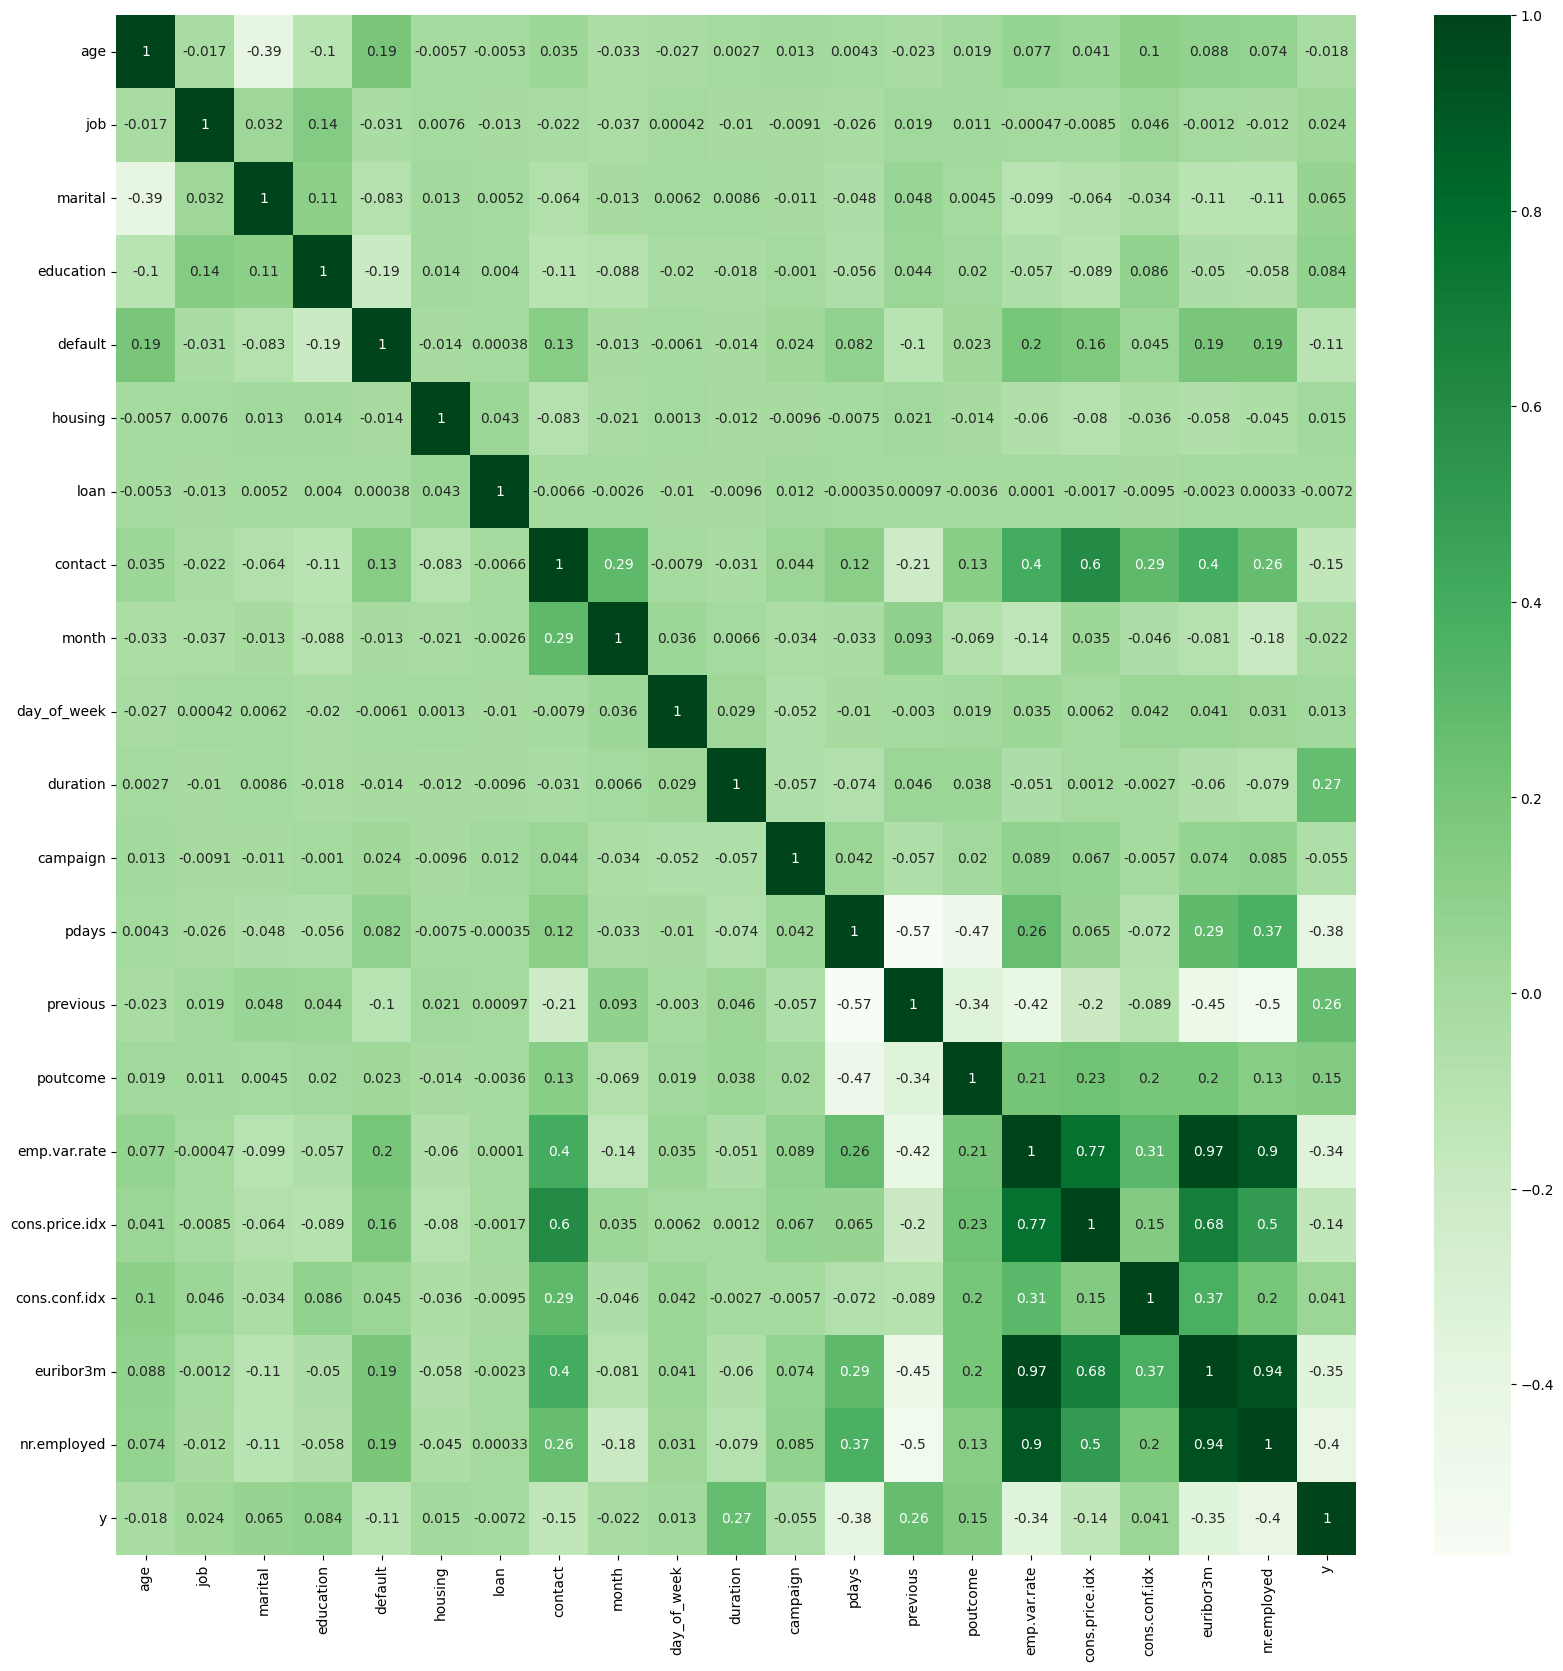

In [27]:
plt.figure(figsize=(20,20))
sns.heatmap(df_bank.corr(), cmap='Greens', annot=True)


In [28]:
# since  there is no strong correlation ( all  are less than +0.5 or -0.5), moved to VIF.
# Variance Inflation Factor - measures multicollinority(inter dependency b/w indepedent variables ie. with in itself),
# if VIF is higher than 5 for a column, then the column affected by the column.

In [29]:
# X = df_bank.iloc[:,:-1]
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35165 entries, 0 to 41186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35165 non-null  float64
 1   job             35165 non-null  int64  
 2   marital         35165 non-null  int64  
 3   education       35165 non-null  int64  
 4   default         35165 non-null  int64  
 5   housing         35165 non-null  int64  
 6   loan            35165 non-null  int64  
 7   contact         35165 non-null  int64  
 8   month           35165 non-null  int64  
 9   day_of_week     35165 non-null  int64  
 10  duration        35165 non-null  float64
 11  campaign        35165 non-null  float64
 12  pdays           35165 non-null  float64
 13  previous        35165 non-null  float64
 14  poutcome        35165 non-null  int64  
 15  emp.var.rate    35165 non-null  float64
 16  cons.price.idx  35165 non-null  float64
 17  cons.conf.idx   35165 non-null  floa

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [31]:
X = df_bank.drop(columns=['y'])
y = df_bank['y']
print(X.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
Index: 35165 entries, 0 to 41186
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35165 non-null  float64
 1   job             35165 non-null  int64  
 2   marital         35165 non-null  int64  
 3   education       35165 non-null  int64  
 4   default         35165 non-null  int64  
 5   housing         35165 non-null  int64  
 6   loan            35165 non-null  int64  
 7   contact         35165 non-null  int64  
 8   month           35165 non-null  int64  
 9   day_of_week     35165 non-null  int64  
 10  duration        35165 non-null  float64
 11  campaign        35165 non-null  float64
 12  pdays           35165 non-null  float64
 13  previous        35165 non-null  float64
 14  poutcome        35165 non-null  int64  
 15  emp.var.rate    35165 non-null  float64
 16  cons.price.idx  35165 non-null  float64
 17  cons.conf.idx   35165 non-null  floa

In [32]:
#find multicollinarity for each column

# column-0
variance_inflation_factor(df_bank.values, 0) # 0 - first column in the matrix

# column-1
variance_inflation_factor(df_bank.values, 1) # 1 - second column in the df_bank.values matrix


np.float64(2.100876264416101)

In [33]:
for ci in range(0, len(df_bank.columns[:-1])):
  print(f'Variance Inflation Factor for - {df_bank.columns[ci]} is :'
  f'{variance_inflation_factor(df_bank.values, ci)}')

Variance Inflation Factor for - age is :22.11469550068186
Variance Inflation Factor for - job is :2.100876264416101
Variance Inflation Factor for - marital is :5.691471188213227
Variance Inflation Factor for - education is :4.5660731911823635
Variance Inflation Factor for - default is :1.4127340300774294
Variance Inflation Factor for - housing is :2.212421671042643
Variance Inflation Factor for - loan is :1.2083255534991084
Variance Inflation Factor for - contact is :2.970156158354014
Variance Inflation Factor for - month is :6.782257845385495
Variance Inflation Factor for - day_of_week is :3.100740514364869
Variance Inflation Factor for - duration is :3.4541002069490987
Variance Inflation Factor for - campaign is :3.615282061031591
Variance Inflation Factor for - pdays is :176.09610100703054
Variance Inflation Factor for - previous is :6.070120770070809
Variance Inflation Factor for - poutcome is :35.00299547106368
Variance Inflation Factor for - emp.var.rate is :38.365660766271084
Va

In [34]:
df_temp_vi = pd.DataFrame({'Features' : X.columns})
df_temp_vi['VIF'] = [variance_inflation_factor(X.values, ci) for ci in range(0, len(X.columns))]
df_temp_vi.sort_values(by=['VIF'], ascending=[False])
# feature vif-value

,Features,VIF
19,nr.employed,43115.201160
16,cons.price.idx,37885.320838
18,euribor3m,322.672944
12,pdays,174.895512
17,cons.conf.idx,143.576459
15,emp.var.rate,37.592081
14,poutcome,34.934345
0,age,22.113993
8,month,6.685085
13,previous,6.070087


In [35]:
# X.drop(columns=['nr.employed'], inplace=True)
# X.drop(columns=['cons.price.idx'], inplace=True)
# X.drop(columns=['pdays'], inplace=True)
# X.drop(columns=['euribor3m'], inplace=True)
# X.drop(columns=['cons.conf.idx'], inplace=True)
# X.drop(columns=['age'], inplace=True)
X.drop(columns=['poutcome'], inplace=True)

#Model Building

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error



In [37]:
# split training and testing data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [38]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24615 entries, 27108 to 18533
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             24615 non-null  float64
 1   job             24615 non-null  int64  
 2   marital         24615 non-null  int64  
 3   education       24615 non-null  int64  
 4   default         24615 non-null  int64  
 5   housing         24615 non-null  int64  
 6   loan            24615 non-null  int64  
 7   contact         24615 non-null  int64  
 8   month           24615 non-null  int64  
 9   day_of_week     24615 non-null  int64  
 10  duration        24615 non-null  float64
 11  campaign        24615 non-null  float64
 12  pdays           24615 non-null  float64
 13  previous        24615 non-null  float64
 14  emp.var.rate    24615 non-null  float64
 15  cons.price.idx  24615 non-null  float64
 16  cons.conf.idx   24615 non-null  float64
 17  euribor3m       24615 non-null  

In [39]:
y_train.shape
y_test.shape
x_train.shape

(24615, 19)

In [40]:
model = LogisticRegression()

In [41]:
model.fit(x_train, y_train,)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [42]:
y_pred = model.predict(x_test)

In [43]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [44]:
accuracy_score(y_test, y_pred)

0.9395260663507109

In [45]:
#confusion matrix
cm_array = confusion_matrix(y_test, y_pred)
cm_array

array([[9606,  163],
       [ 475,  306]])

In [51]:
?confusion_matrix

<Axes: >

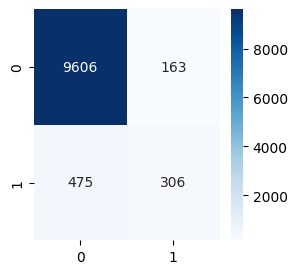

In [53]:
plt.figure(figsize=(3,3))
sns.heatmap(cm_array, annot=True, cmap='Blues', fmt='d')